In [55]:
import pycaret
pycaret.__version__

'2.3.10'

<h3>Завантаження датасету:</h3>

In [56]:
from pycaret.datasets import get_data
dataset = get_data('pokemon')

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [57]:
dataset.shape

(800, 13)

In [58]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB



<b>Даний датасет характерізує персонажів гри: їх імʼя, здібність, категорію, здоровʼя, силу атаки, швидкість, покоління, легендарність. <br>
Датасет має 800 записів та 13 атрибутів.  <br>
Для аналізу даних буде використаний метод кластеризації для наглядного розподілу персонажів за класами.</b>


<h3>Імпорт методів для кластеризації та підготовка даних:</h3>

In [70]:
from pycaret import clustering
s = clustering.setup(data = dataset,
                    normalize = True,
                    ignore_features = ['Name','Type 1','Type 2','Generation','Legendary'])

,Description,Value
0,session_id,387
1,Original Data,"(800, 13)"
2,Missing Values,True
3,Numeric Features,8
4,Categorical Features,0
5,Ordinal Features,False
6,High Cardinality Features,False
7,High Cardinality Method,None
8,Transformed Data,"(800, 8)"
9,CPU Jobs,-1


<h3>Створення моделі:</h3>

In [71]:
kmeans = clustering.create_model('kmeans', num_clusters=4)
kmeans

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2077,224.846,1.7544,0,0,0


KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=10, n_jobs=-1, precompute_distances='deprecated',
       random_state=387, tol=0.0001, verbose=0)

In [73]:
clustering.plot_model(kmeans, plot='cluster')

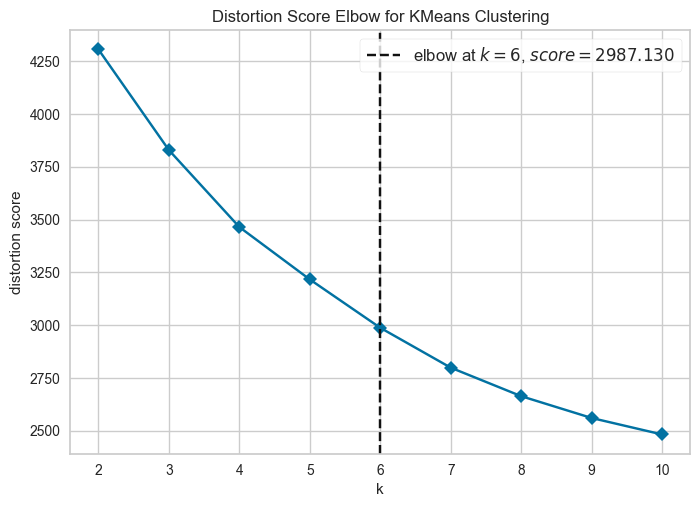

In [74]:
clustering.plot_model(kmeans, plot='elbow')

In [75]:
result = clustering.assign_model(kmeans)
result.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,Cluster 1
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,Cluster 3
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,Cluster 3
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,Cluster 2
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,Cluster 1


<h3>Збереження моделі у файл .pkl:</h3>

In [76]:
clustering.save_model(kmeans, model_name='pokemon_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=[],
                                       display_types=True,
                                       features_todrop=['Name', 'Type 1',
                                                        'Type 2', 'Generation',
                                                        'Legendary'],
                                       id_columns=[], ml_usecase='regression',
                                       numerical_features=[],
                                       target='UNSUPERVISED_DUMMY_TARGET',
                                       time_features=[])),
                 ('imputer',
                  Simple_Imputer(categorical_strategy='most frequent',
                                 fill_v...
                 ('fix_perfect', 'passthrough'),
                 ('clean_names', Clean_Colum_Names()),
                 ('feature_select', 'passthrough'), ('fix_multi', 'passthrough')